# Nominal MPC Generation
Uses an MPC controller to generate nominal control inputs for each episode. Note that this assumes there are no CBFs generated by any required keep-out regions.

In [1]:
import pathlib
import itertools
import h5py
import numpy as np

from dataclasses import dataclass
from scipy.integrate import solve_ivp

from typing import Callable

from mpc_controller import (
    Trajectory,
    DynExtUnicycleMCPParams,
    dyn_ext_unicycle_model_step,
    dyn_ext_unicycle_cost,
    gen_mpc_controls,
)

import matplotlib.pyplot as plt

from multiprocessing import Pool
import tqdm

In [2]:
episodes_train_dir = pathlib.Path("../data/episodes/train")
episodes_test_dir = pathlib.Path("../data/episodes/test")

In [3]:
# load all the episodes from file into memory (so we can parallelize nominal
# control input generation for performance)


def load_from_h5(h5_file_dir):
    episodes = []
    files = []
    for file in h5_file_dir.iterdir():
        if file.name == ".gitkeep":
            continue  # don't try to load this one
        episode = dict()
        with h5py.File(file, "r") as f:
            f.visititems(lambda name, obj: episode.update({name: np.asarray(obj)}))
            episode.update(f.attrs)
        episodes.append(episode)
        files.append(file.name)
    return episodes, files


train_episodes, train_files = load_from_h5(episodes_train_dir)
test_episodes, test_files = load_from_h5(episodes_test_dir)

train_episodes[0]

{'ddx_traj': array([-0.16974615, -0.16726077, -0.16477539, -0.16229   , -0.15980462,
        -0.15731924, -0.15483385, -0.15234847, -0.14986308, -0.1473777 ,
        -0.14489232, -0.14240693, -0.13992155, -0.13743616, -0.13495078,
        -0.1324654 , -0.12998001, -0.12749463, -0.12500925, -0.12252386,
        -0.12003848, -0.11755309, -0.11506771, -0.11258233, -0.11009694,
        -0.10761156, -0.10512617, -0.10264079, -0.10015541, -0.09767002,
        -0.09518464, -0.09269926, -0.09021387, -0.08772849, -0.0852431 ,
        -0.08275772, -0.08027234, -0.07778695, -0.07530157, -0.07281618,
        -0.0703308 , -0.06784542, -0.06536003, -0.06287465, -0.06038927,
        -0.05790388, -0.0554185 , -0.05293311, -0.05044773, -0.04796235,
        -0.04547696, -0.04299158, -0.04050619, -0.03802081, -0.03553543,
        -0.03305004, -0.03056466, -0.02807928, -0.02559389, -0.02310851,
        -0.02062312, -0.01813774, -0.01565236, -0.01316697, -0.01068159,
        -0.00819621, -0.00571082, -0.00

In [4]:
dist_cost = 5.0
ang_cost = 2.0

u_cost = 2.75*np.diag([1.0, 1.2])

k_base = 2.0
future_pred_cost_factor = lambda k: k_base**k if k > 0 else 1.0

num_mpc_steps = 5
mpc_dt = 0.5

In [5]:
def gen_controls_for_episode(
    episode,
    dist_cost,
    ang_cost,
    u_cost,
    future_pred_cost_factor,
    num_mpc_steps,
):
    # generates the state and control history for the episode

    p_hist = []  # state history
    u_hist = []  # control history

    traj_err_hist = []  # position tracking error

    # really only care about the randomized position as given the distribution
    # it will have angles distributed with respect to the ideal trajectory
    # anyways so this should be fine
    # NOTE: also start at zero velocity or angular velocity
    p_curr = np.array([*episode["start_pos"], 0.0, 0.0, 0.0])
    u_curr = np.zeros(2)

    # print(f"Start pos: {p_curr}")

    dt = episode["sample_time"]

    # setup the trajectory and parameters
    t = episode["t_traj"]

    traj = Trajectory(
        dt,
        t,
        episode["x_traj"],
        episode["y_traj"],
        episode["dx_traj"],
        episode["dy_traj"],
        episode["ddx_traj"],
        episode["ddy_traj"],
    )

    params = DynExtUnicycleMCPParams(
        dist_cost, ang_cost, u_cost, future_pred_cost_factor, traj
    )

    for i in range(len(t)):
        t_curr = t[i]

        # print(f"t_curr: {t_curr}")

        u_optimal, _ = gen_mpc_controls(
            t_curr,
            p_curr,
            num_mpc_steps,
            mpc_dt,
            u_curr,
            params,
            dyn_ext_unicycle_model_step,
            dyn_ext_unicycle_cost,
        )

        p_hist.append(p_curr)
        u_hist.append(u_optimal)

        # NOTE: technically this trajectory error can be computed afterwards but
        # for convenience it will be computed here and is immediately available
        x_traj_curr, y_traj_curr, _, _, _, _ = traj(t_curr)
        traj_err = np.array([x_traj_curr - p_curr[0], y_traj_curr - p_curr[1]])
        traj_err_hist.append(traj_err)

        # updates the current position afterwards so it considers the initial
        # condition when generating the frist control input
        p_curr = dyn_ext_unicycle_model_step(t_curr, dt, p_curr, u_optimal, params)

        # for testing
        # if i > 3000:
        #     break

    return np.array(p_hist), np.array(u_hist), np.array(traj_err_hist)

In [6]:
test_episode = train_episodes[2]
p_hist, u_hist, traj_err_hist = gen_controls_for_episode(
    test_episode,
    dist_cost,
    ang_cost,
    u_cost,
    future_pred_cost_factor,
    num_mpc_steps,
)

In [7]:
p_hist.shape
u_hist

array([[ 1.07739908e+00, -1.25489843e+00],
       [ 9.56459819e-01, -1.11860347e+00],
       [ 8.45360455e-01, -9.90299172e-01],
       [ 7.43483859e-01, -8.70018740e-01],
       [ 6.50244359e-01, -7.57704332e-01],
       [ 5.65089343e-01, -6.53220354e-01],
       [ 4.87504927e-01, -5.56368455e-01],
       [ 4.17008468e-01, -4.66901230e-01],
       [ 3.53148181e-01, -3.84535529e-01],
       [ 2.95494177e-01, -3.08960744e-01],
       [ 2.43637548e-01, -2.39849629e-01],
       [ 1.97185717e-01, -1.76866899e-01],
       [ 1.55759737e-01, -1.19674458e-01],
       [ 1.18992629e-01, -6.79364083e-02],
       [ 8.65285039e-02, -2.13233830e-02],
       [ 5.80231755e-02,  2.04846768e-02],
       [ 3.31436428e-02,  5.77964581e-02],
       [ 1.15691611e-02,  9.09081772e-02],
       [-7.00636609e-03,  1.20101683e-01],
       [-2.28744208e-02,  1.45645430e-01],
       [-3.63111377e-02,  1.67793163e-01],
       [-4.75739764e-02,  1.86786874e-01],
       [-5.69036580e-02,  2.02852705e-01],
       [-6.

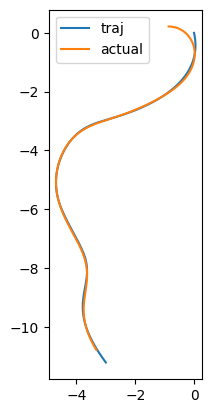

In [8]:
# fairly decent adherence to the trajectory and if anymore aggressive then the
# commanded inputs will be higher than what we'd expect for a comparative robot

fig, ax = plt.subplots(1, 1)

ax.plot(test_episode["x_traj"], test_episode["y_traj"], label="traj")
ax.plot(p_hist[:, 0], p_hist[:, 1], label="actual")

ax.set_aspect("equal")
ax.legend()

plt.show()

In [9]:
def gen_controls_for_episode_wrapped(episode):
    # unable to use a lambda function so this just feeds in the parameter
    # values and can be used with multiprocessing

    return gen_controls_for_episode(
        episode,
        dist_cost,
        ang_cost,
        u_cost,
        future_pred_cost_factor,
        num_mpc_steps,
    )


# sets up a subset of the data to evaluate (if necessary)
train_episodes_subset = train_episodes[:]
test_episodes_subset = test_episodes[:]

with Pool(processes=28) as pool:
    print("Beginning computation of mpc controller for train episodes...")
    train_episodes_results = list(
        tqdm.tqdm(
            pool.imap(gen_controls_for_episode_wrapped, train_episodes_subset),
            total=len(train_episodes_subset),
        )
    )
    print("Beginning computation of mpc controller for test episodes...")
    test_episodes_results = list(
        tqdm.tqdm(
            pool.imap(gen_controls_for_episode_wrapped, test_episodes_subset),
            total=len(test_episodes_subset),
        )
    )

Beginning computation of mpc controller for train episodes...


100%|██████████| 6/6 [00:44<00:00,  7.40s/it]


Beginning computation of mpc controller for test episodes...


100%|██████████| 3/3 [00:37<00:00, 12.36s/it]


In [10]:
episodes_train_dir = pathlib.Path("../data/nominal_mpc/train")
episodes_test_dir = pathlib.Path("../data/nominal_mpc/test")

# empty these repositories so we have no issues when writing the episodes that
# were generated in the preceding section
for file in itertools.chain(episodes_train_dir.iterdir(), episodes_test_dir.iterdir()):
    if file.name == ".gitkeep":
        continue  # don't delete this file
    file.unlink()

# writes all the training data
num_train_results = len(train_episodes_results)
num_test_results = len(test_episodes_results)

for i in range(num_train_results + num_test_results):
    p_hist, u_hist, traj_err_hist = (
        train_episodes_results[i]
        if i < num_train_results
        else test_episodes_results[i - num_train_results]
    )

    file = (
        episodes_train_dir.joinpath(train_files[i])
        if i < num_train_results
        else episodes_test_dir.joinpath(test_files[i - num_train_results])
    )
    with h5py.File(file, "w") as f:
        f.create_dataset("p_hist", data=p_hist)
        f.create_dataset("u_hist", data=u_hist)
        f.create_dataset("traj_err_hist", data=traj_err_hist)

        # write the parameters used for the mpc controller
        f.attrs["dist_cost"] = dist_cost
        f.attrs["ang_cost"] = ang_cost
        f.attrs["u_cost"] = u_cost
        f.attrs["k_base"] = k_base
        f.attrs["num_mpc_steps"] = num_mpc_steps
        f.attrs["mpc_dt"] = mpc_dt

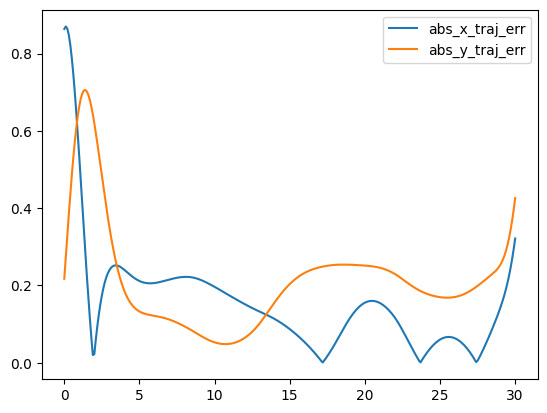

In [11]:
err = train_episodes_results[2][2]  # trajectory error

fig, ax = plt.subplots(1, 1)

ax.plot(train_episodes_subset[2]["t_traj"], abs(err[:, 0]), label="abs_x_traj_err")
ax.plot(train_episodes_subset[2]["t_traj"], np.abs(err[:, 1]), label="abs_y_traj_err")

ax.legend()

plt.show()